Task 1 — Identify Data Quality Issues

In [14]:
import pandas as pd

df = pd.read_csv("Student_performance_data _.csv")

df.info()
df.isnull().sum()
df.duplicated().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


Task 2 — Missing Value Strategy

In [15]:
df.fillna(df.mean(numeric_only=True), inplace=True)

Task 3 — Detect & Handle Outliers

In [16]:
Q1 = df['Absences'].quantile(0.25)
Q3 = df['Absences'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Absences'] >= lower) & (df['Absences'] <= upper)]

Task 4 — Normalize

In [17]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

df[['Absences','StudyTimeWeekly','GPA']] = minmax.fit_transform(
    df[['Absences','StudyTimeWeekly','GPA']]
)

Min-Max


In [18]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

df[['Absences','StudyTimeWeekly','GPA']] = minmax.fit_transform(
    df[['Absences','StudyTimeWeekly','GPA']]
)

Z-score


In [19]:
from sklearn.preprocessing import StandardScaler

zscore = StandardScaler()

df[['Absences','StudyTimeWeekly','GPA']] = zscore.fit_transform(
    df[['Absences','StudyTimeWeekly','GPA']]
)

Task 5 — Apply PCA

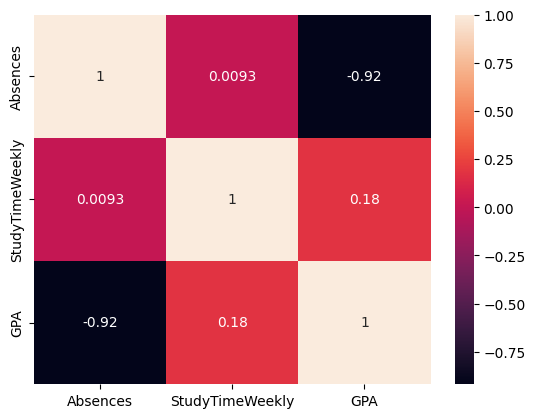

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['Absences','StudyTimeWeekly','GPA']].corr()
sns.heatmap(corr, annot=True)
plt.show()

PCA

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

principal_components = pca.fit_transform(
    df[['Absences','StudyTimeWeekly','GPA']]
)

df_pca = pd.DataFrame(principal_components, columns=['PC1','PC2'])

df[['PC1','PC2']] = df_pca